In [106]:
import numpy as np
from matplotlib import pyplot as plt
import torch

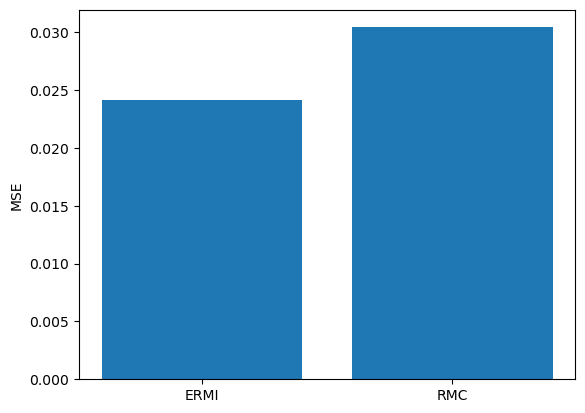

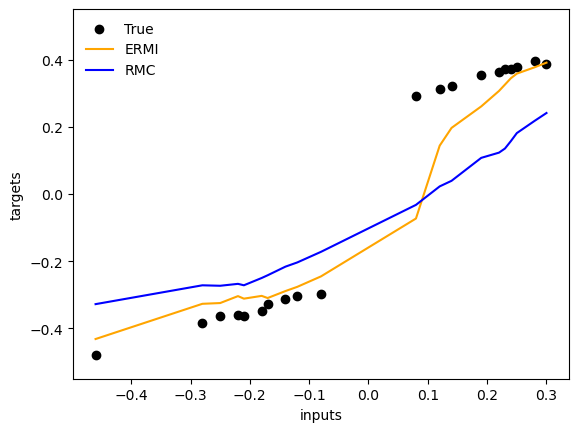

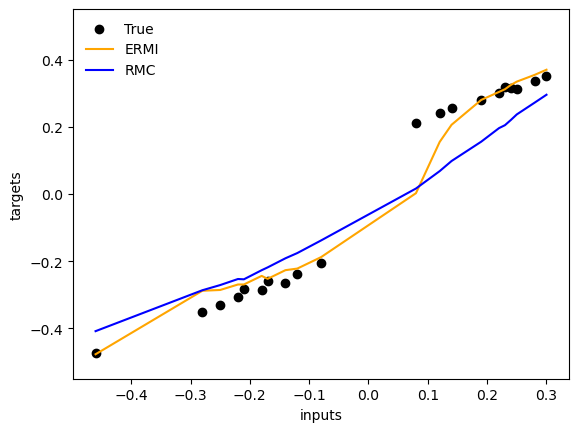

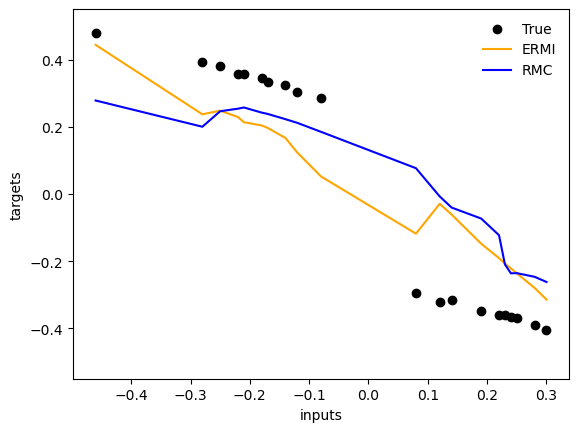

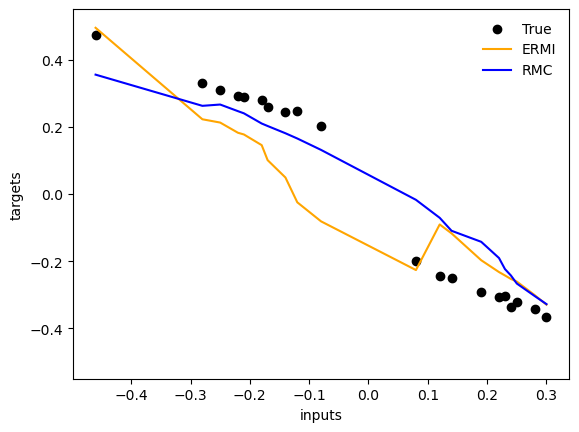

In [117]:
mode='extrapolation'
ermi = np.load(f'/scratch/gpfs/GRIFFITHS/aj9225/meta-learning-ecological-priors-from-llms/functionlearning/data/model_simulation/env=claude_dim1_maxsteps25_model=transformer_num_episodes100000_num_hidden=256_lr0.0003_num_layers=6_d_model=64_num_head=8_noise0.0_shuffleTrue_run=0_experiment_functions_{mode}.npz')
#env=claude_dim1_maxsteps25_model=transformer_num_episodes100000_num_hidden=256_lr0.0003_num_layers=6_d_model=64_num_head=8_noise0.0_shuffleTrue_run=0_handcrafted_functions.npz')
rmc = np.load(f'/scratch/gpfs/GRIFFITHS/aj9225/meta-learning-ecological-priors-from-llms/functionlearning/data/model_simulation/env=synthetic_dim1_model=transformer_num_episodes100000_num_hidden=256_lr0.0003_num_layers=6_d_model=64_num_head=8_noise0.01_shuffleTrue_run=0_synthetic_experiment_functions_{mode}.npz')
# /env=synthetic_dim1_model=transformer_num_episodes100000_num_hidden=256_lr0.0003_num_layers=6_d_model=64_num_head=8_noise0.01_shuffleTrue_run=0_synthetic_handcrafted_functions.npz')

assert ermi['model_errors'].shape==rmc['model_errors'].shape, "not comparing the same results"
plt.bar(['ERMI', 'RMC'], [ermi['model_errors'].mean(), rmc['model_errors'].mean()])
plt.ylabel('MSE')
plt.show() 

# x = torch.linspace(0, 1, 20)-0.5
num_functions = ermi['targets'].squeeze().shape[1]

plot_samples = np.arange(num_functions-1)
for samples in np.arange(1, 60, 15):
    sort_args=  np.argsort(ermi['human_preds'].squeeze().T[1:, samples])
    plt.scatter(ermi['human_preds'].squeeze().T[1:, samples][sort_args], ermi['targets'].squeeze().T[1:, samples][sort_args], c='black')
    plt.plot(ermi['human_preds'].squeeze().T[1:, samples][sort_args], ermi['model_preds'].squeeze().T[1:, samples][sort_args], c='orange')
    plt.plot(rmc['human_preds'].squeeze().T[1:, samples][sort_args], rmc['model_preds'].squeeze().T[1:, samples][sort_args], c='blue')
    plt.legend(['True', 'ERMI', "RMC"], frameon=False)
    plt.xlabel('inputs')
    plt.ylabel('targets')
    plt.ylim([-0.55, 0.55])
    # plt.savefig(f'figure_{samples}.png')
    plt.show()

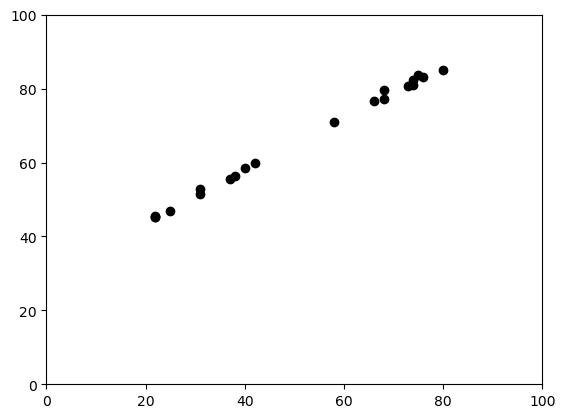

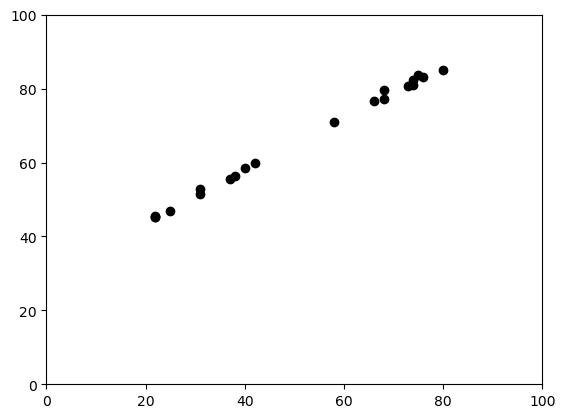

In [66]:
plot_samples = np.arange(0, 2)
for samples in plot_samples:
    plt.scatter(ermi['raw_inputs'].squeeze().T[1:, samples], ermi['raw_targets'].squeeze().T[1:, samples],  c='black')
    # plt.plot(ermi['human_preds'].squeeze().T[1:, samples], ermi['model_preds'].squeeze().T[1:, samples], c='orange')
    plt.xlim([0,100])
    plt.ylim([0,100])
    plt.show()


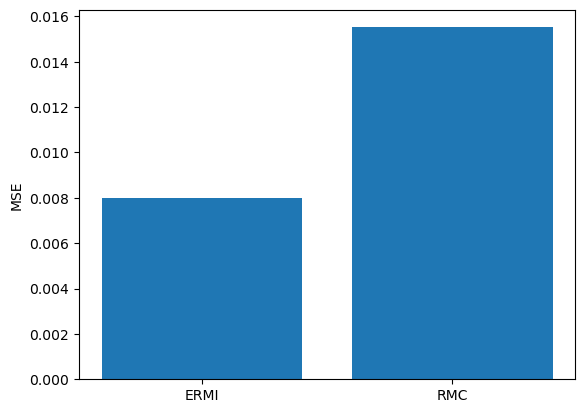

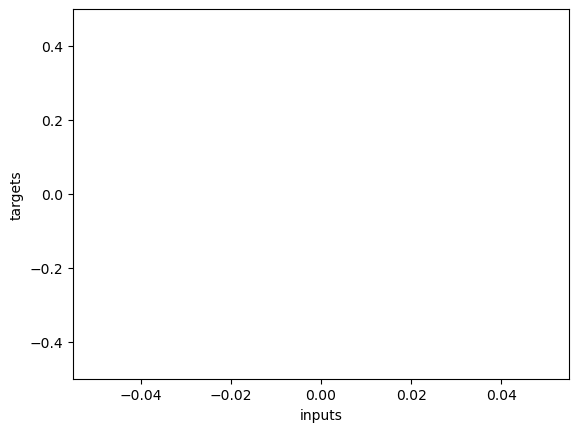

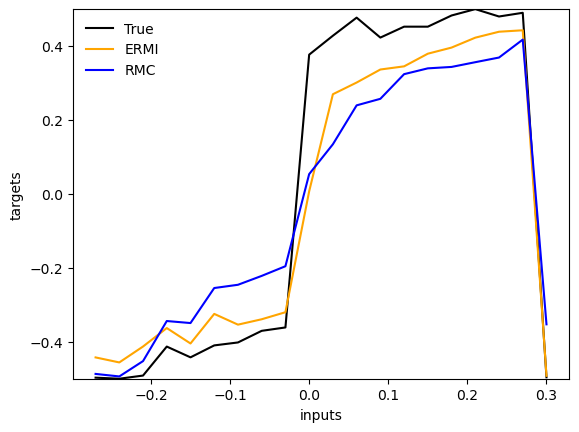

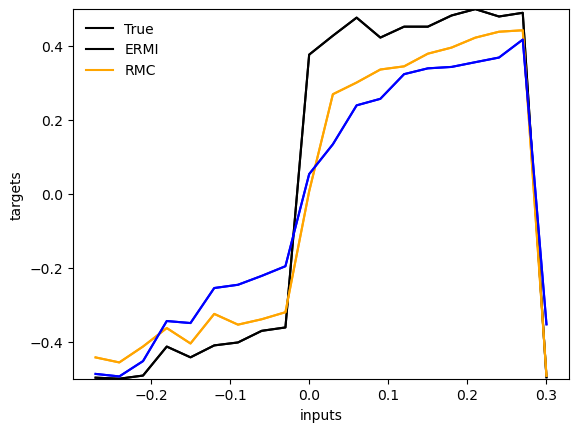

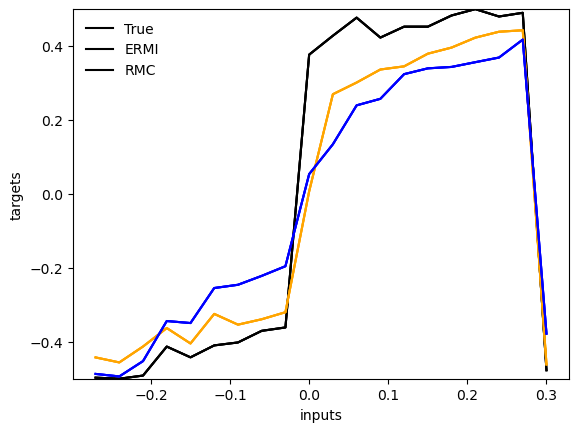

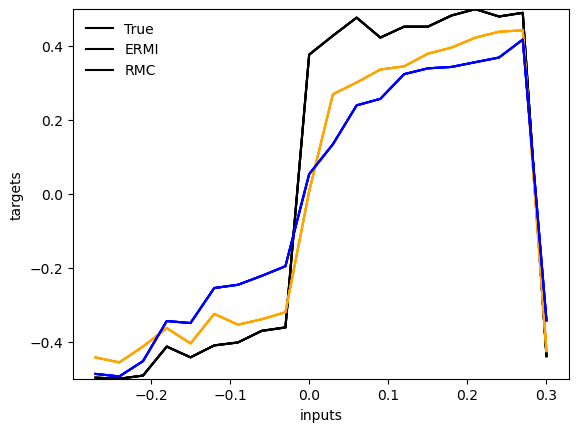

In [97]:
mode='interpolation'
ermi = np.load(f'/scratch/gpfs/GRIFFITHS/aj9225/meta-learning-ecological-priors-from-llms/functionlearning/data/model_simulation/env=claude_dim1_maxsteps25_model=transformer_num_episodes100000_num_hidden=256_lr0.0003_num_layers=6_d_model=64_num_head=8_noise0.0_shuffleTrue_run=0_experiment_functions_{mode}.npz')
#env=claude_dim1_maxsteps25_model=transformer_num_episodes100000_num_hidden=256_lr0.0003_num_layers=6_d_model=64_num_head=8_noise0.0_shuffleTrue_run=0_handcrafted_functions.npz')
rmc = np.load(f'/scratch/gpfs/GRIFFITHS/aj9225/meta-learning-ecological-priors-from-llms/functionlearning/data/model_simulation/env=synthetic_dim1_model=transformer_num_episodes100000_num_hidden=256_lr0.0003_num_layers=6_d_model=64_num_head=8_noise0.01_shuffleTrue_run=0_synthetic_experiment_functions_{mode}.npz')
# /env=synthetic_dim1_model=transformer_num_episodes100000_num_hidden=256_lr0.0003_num_layers=6_d_model=64_num_head=8_noise0.01_shuffleTrue_run=0_synthetic_handcrafted_functions.npz')

assert ermi['model_errors'].shape==rmc['model_errors'].shape, "not comparing the same results"
plt.bar(['ERMI', 'RMC'], [ermi['model_errors'].mean(), rmc['model_errors'].mean()])
plt.ylabel('MSE')
plt.show() 

# x = torch.linspace(0, 1, 20)-0.5
num_data = 21
scale = 0.30
num_functions = 5
c = 0.5

x= torch.linspace(-1, 1, num_data)
# x = torch.cat((torch.linspace(0, c, num_data//2), torch.linspace(c, 1, num_data//2)), dim=0)
def stacked_normalized(data, scale):
    data_min = data.min()
    data_max = data.max()
    return 2 * scale * (data - data_min) / (data_max - data_min + 1e-6) - scale

x = stacked_normalized(x.reshape(-1), scale)
inputs = x.tile((num_functions,)).reshape(num_functions, num_data)
plot_samples = np.arange(0, num_functions)
for samples in plot_samples:
    plt.plot(inputs.T[1:, :samples], ermi['targets'].squeeze().T[1:, samples], 'black')
    plt.plot(inputs.T[1:, :samples], ermi['model_preds'].squeeze().T[1:, samples], c='orange')
    plt.plot(inputs.T[1:, :samples], rmc['model_preds'].squeeze().T[1:, samples], c='blue')
    plt.legend(['True', 'ERMI', "RMC"], frameon=False)
    plt.xlabel('inputs')
    plt.ylabel('targets')
    plt.ylim([-0.5, 0.5])
    # plt.savefig(f'figure_{samples}.png')
    plt.show()

In [166]:
aa = torch.tensor([[-0.5000,  0.0000],
        [-0.4565,  0.5000],
        [-0.4130,  0.4565],
        [-0.3696,  0.4130],
        [-0.3261,  0.3696],
        [-0.2826,  0.3261],
        [-0.2391,  0.2826],
        [-0.1957,  0.2391],
        [-0.1522,  0.1957],
        [-0.1087,  0.1522],
        [-0.0652,  0.1087],
        [-0.0217,  0.0652],
        [ 0.0217,  0.0217],
        [ 0.0652, -0.0217],
        [ 0.1087, -0.0652],
        [ 0.1522, -0.1087],
        [ 0.1957, -0.1522],
        [ 0.2391, -0.1957],
        [ 0.2826, -0.2391],
        [ 0.3261, -0.2826],
        [ 0.3696, -0.3261],
        [ 0.4130, -0.3696],
        [ 0.4565, -0.4130],
        [ 0.5000, -0.4565]])

In [167]:
model_preds = torch.tensor([[-0.4350],
        [ 0.3247],
        [ 0.3967],
        [ 0.2792],
        [ 0.2071],
        [ 0.1429],
        [ 0.1005],
        [ 0.0523],
        [ 0.0095],
        [-0.0338],
        [-0.0708],
        [-0.1212],
        [-0.1726],
        [-0.2119],
        [-0.2433],
        [-0.2626],
        [-0.2797],
        [-0.2999],
        [-0.3233],
        [-0.3509],
        [-0.3831],
        [-0.4170],
        [-0.4403],
        [-0.4576]])

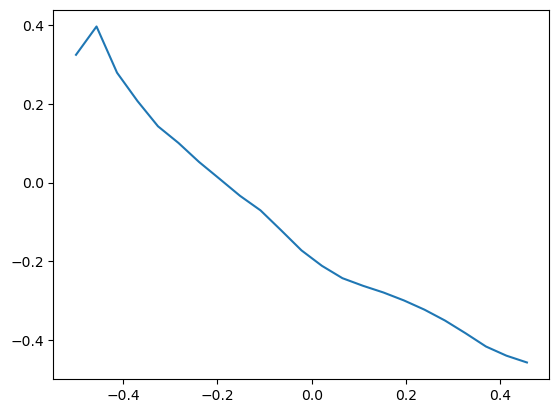

In [172]:
plt.plot(aa[:-1, 0], model_preds[1:, 0]);

In [169]:
bb = torch.tensor([[-5.0000e-01,  0.0000e+00],
        [-4.5833e-01,  5.0000e-01],
        [-4.1667e-01,  4.5833e-01],
        [-3.7500e-01,  4.1666e-01],
        [-3.3333e-01,  3.7500e-01],
        [-2.9167e-01,  3.3333e-01],
        [-2.5000e-01,  2.9166e-01],
        [-2.0833e-01,  2.5000e-01],
        [-1.6667e-01,  2.0833e-01],
        [-1.2500e-01,  1.6666e-01],
        [-8.3334e-02,  1.2500e-01],
        [-4.1667e-02,  8.3332e-02],
        [-2.3842e-07,  4.1665e-02],
        [ 4.1666e-02, -1.4603e-06],
        [ 8.3333e-02, -4.1668e-02],
        [ 1.2500e-01, -8.3334e-02],
        [ 1.6667e-01, -1.2500e-01],
        [ 2.0833e-01, -1.6667e-01],
        [ 2.5000e-01, -2.0833e-01],
        [ 2.9167e-01, -2.5000e-01],
        [ 3.3333e-01, -2.9167e-01],
        [ 3.7500e-01, -3.3333e-01],
        [ 4.1667e-01, -3.7500e-01],
        [ 4.5833e-01, -4.1667e-01],
        [ 5.0000e-01, -4.5833e-01]])

In [170]:
model_preds2 = torch.tensor([[-0.4350],
        [ 0.3230],
        [ 0.3976],
        [ 0.2820],
        [ 0.2164],
        [ 0.1492],
        [ 0.1094],
        [ 0.0635],
        [ 0.0205],
        [-0.0233],
        [-0.0577],
        [-0.0993],
        [-0.1542],
        [-0.1940],
        [-0.2258],
        [-0.2501],
        [-0.2648],
        [-0.2840],
        [-0.3057],
        [-0.3314],
        [-0.3577],
        [-0.3873],
        [-0.4150],
        [-0.4375],
        [-0.4578]])

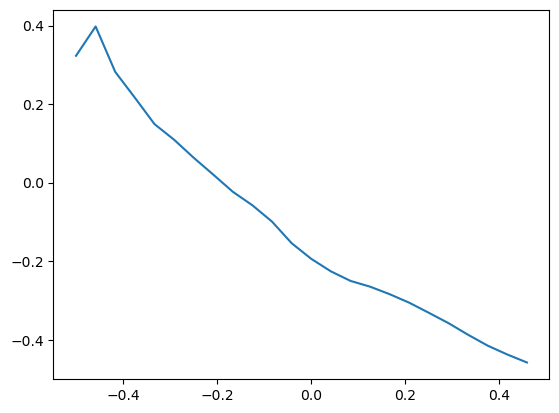

In [173]:
plt.plot(bb[:-1, 0], model_preds2[1:, 0]);

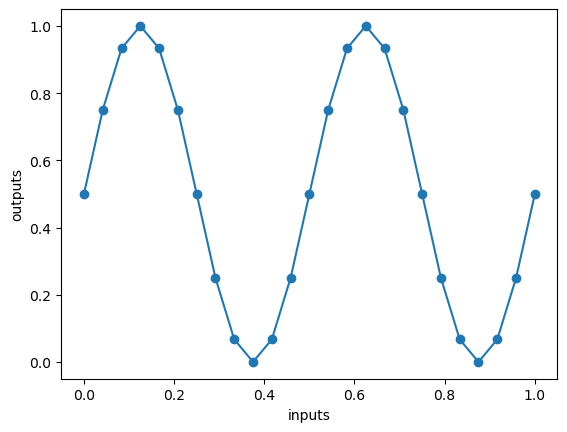

In [23]:
x = np.linspace(0, 1, 25)
f = 50
amp = offset = 0.5
y = amp*np.sin(2*np.pi*f*x) + offset
plt.scatter(x,y)
plt.plot(x,y)
plt.xlabel('inputs')
plt.ylabel('outputs')
plt.show()

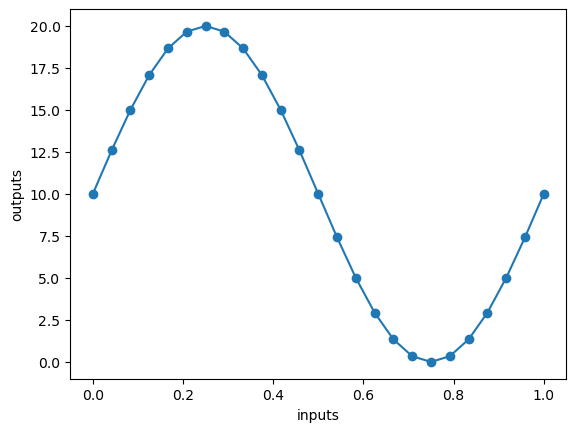

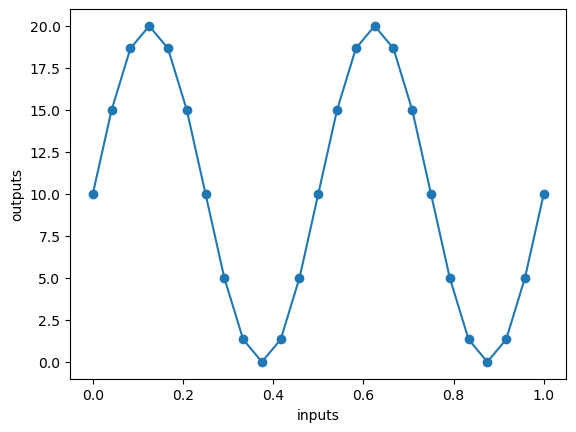

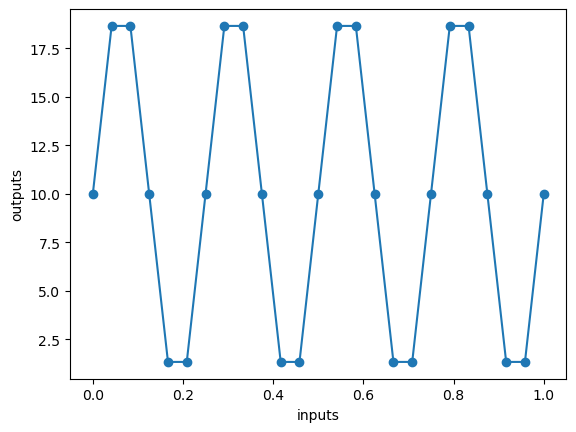

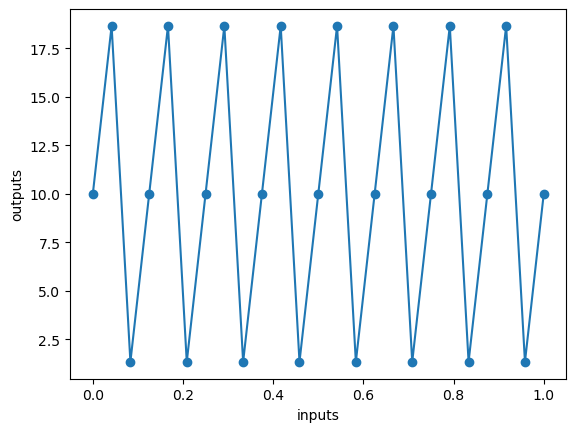

In [49]:
x = np.linspace(0, 1, 25)
freqs = [1, 2, 4, 8]
amps = offsets =  [10, 10, 10, 10]  #np.linspace(10) # 100, 10)
for (f, amp, offset) in zip(freqs, amps, offsets):
    y = amp*np.sin(2*np.pi*f*x) + offset
    plt.scatter(x,y)
    plt.plot(x,y)
    plt.xlabel('inputs')
    plt.ylabel('outputs')
    plt.show()

In [52]:
import numpy as np
import pandas as pd

def make_sine_data(x_start, x_end, n_points, f, amp, offset):
    x = np.linspace(x_start, x_end, n_points)
    y = amp * np.sin(2 * np.pi * f * x) + offset
    return x, y

# example: different params per task
tasks = [
    {"task": 1, "f": 2, "amp": 10, "offset": 10},
    {"task": 2, "f": 4, "amp": 10, "offset": 10},
    {"task": 3, "f": 6, "amp": 10, "offset": 10},
    {"task": 4, "f": 8, "amp": 10, "offset": 10},
]

all_rows = []
participant = 1

for cfg in tasks:
    x, y = make_sine_data(
        x_start=0,
        x_end=1,
        n_points=25,
        f=cfg["f"],
        amp=cfg["amp"],
        offset=cfg["offset"],
    )
    for xi, yi in zip(x, y):
        all_rows.append(
            {
                "participant": participant,
                "task": cfg["task"],
                "x": xi,
                "y": yi,
            }
        )

df = pd.DataFrame(all_rows)
df.to_csv("sine_tasks.csv", index=False)
# df.head()
df

,participant,task,x,y
0,1,1,0.000000,10.000000
1,1,1,0.041667,15.000000
2,1,1,0.083333,18.660254
3,1,1,0.125000,20.000000
4,1,1,0.166667,18.660254
...,...,...,...,...
95,1,4,0.833333,1.339746
96,1,4,0.875000,10.000000
97,1,4,0.916667,18.660254
98,1,4,0.958333,1.339746


In [202]:
import numpy as np
import pandas as pd
import torch.nn as nn
import torch
import torch.nn.utils.rnn as rnn_utils
from torch.distributions import Beta, Bernoulli, Categorical, MultivariateNormal
import torch.multiprocessing as mp
from sklearn.preprocessing import MinMaxScaler
# from model_utils import MLP
import math

In [250]:
class HandCraftedFunctions(nn.Module):
    """
    Generate function learning tasks for evaluation of ERMI and humans on interpolation and extrapolation
    """

    def __init__(self, max_steps=20, num_dims=1, scale=0.5, dynamic_scaling=False, batch_size=1000, mode='test',  device='cpu', noise=0., normalize_inputs=False, save_data=True):
        """
        Initialise the environment
        Args:
            data: path to csv file containing data
            max_steps: number of steps in each episode
            num_dims: number of dimensions in each input
            batch_size: number of tasks in each batch
        """
        super(HandCraftedFunctions, self).__init__()
    
        self.device = torch.device(device)   
        self.max_steps = max_steps
        self.num_choices = 1
        self.num_dims = num_dims
        self.mode = mode
        self.batch_size = batch_size
        self.scale = scale
        self.dynamic_scaling = dynamic_scaling
        self.noise = noise
        self.normalize = normalize_inputs
        self.save_data = save_data
        self.register_buffer('sin_freqs', torch.tensor([1, 2, 4, 6], dtype=torch.float32))
        self.register_buffer('sin_phases', torch.tensor([0.]*4))
        self.register_buffer('sin_amps', torch.tensor([10.]*4))
        self.register_buffer('sin_offsets', torch.tensor([10.]*4))
        self.register_buffer('lin_weights', torch.tensor([4., 6., 8., 10.], dtype=torch.float32))
        self.register_buffer('lin_intercepts', torch.tensor([0., 5., 10., 15.], dtype=torch.float32))
    
    def exponential(self, x, weight, intercept, scale):
        return weight[:, None] * torch.exp(scale[:, None] * x) + intercept[:, None]

    def sinusoidal(self, x):
        """
        Vectorized sinusoidal function that handles batch broadcasting.
        """
        
        idxs = torch.arange(len(self.sin_freqs), device=self.device) % len(self.sin_freqs)
        freqs = self.sin_freqs[idxs].unsqueeze(1)
        phs = self.sin_phases[idxs].unsqueeze(1)
        amps = self.sin_amps[idxs].unsqueeze(1)
        offs = self.sin_offsets[idxs].unsqueeze(1)
    
        return amps * torch.sin(x.unsqueeze(0) * freqs * 2 * np.pi - phs) + offs
    
    def positive_linear(self, x):
        
        idxs = torch.arange(len(self.lin_weights), device=self.device) % len(self.lin_weights)
        weights = self.lin_weights[idxs].unsqueeze(1)
        intercepts = self.lin_intercepts[idxs].unsqueeze(1)
        return weights * x + intercepts

    def negative_linear(self, x):

        idxs = torch.arange(len(self.lin_weights), device=self.device) % len(self.lin_weights)
        weights = self.lin_weights[idxs].unsqueeze(1)
        intercepts = self.lin_intercepts[idxs].unsqueeze(1)
        return -weights * x + intercepts

    def sample_function(self, function, x):

        if function == 'periodic':
            targets = self.sinusoidal(x).to(self.device)
        elif function == 'pos_linear':
            targets = self.positive_linear(x).to(self.device)
        elif function == 'neg_linear':
            targets = self.negative_linear(x).to(self.device)
        elif function == 'pos_neg_linear':
            pos_linear = self.positive_linear(x[:int(self.max_steps/2)]).to(self.device)
            self.lin_weights = self.lin_weights[torch.randperm(len(self.lin_weights))]
            self.lin_intercepts = self.lin_intercepts[torch.randperm(len(self.lin_intercepts))]
            neg_linear = self.negative_linear(x[int(self.max_steps/2):]).to(self.device)
            targets = torch.cat((pos_linear, neg_linear), dim=1)
        elif function == 'neg_pos_linear':
            neg_linear = self.negative_linear(x[:int(self.max_steps/2)]).to(self.device)
            self.lin_weights = self.lin_weights[torch.randperm(len(self.lin_weights))]
            self.lin_intercepts = self.lin_intercepts[torch.randperm(len(self.lin_intercepts))]
            pos_linear = self.positive_linear(x[int(self.max_steps/2):]).to(self.device)
            targets = torch.cat((neg_linear, pos_linear), dim=1)
        elif function == 'pos_linear_periodic':
            pos_linear = self.positive_linear(x[:int(self.max_steps/2)]).to(self.device)
            sinusoidal = self.sinusoidal(x[:int(self.max_steps/2):]).to(self.device)
            targets = torch.cat((pos_linear, sinusoidal), dim=1)
        elif function == 'periodic_pos_linear':
            sinusoidal = self.sinusoidal(x[:int(self.max_steps/2)]).to(self.device)
            pos_linear = self.positive_linear(x[int(self.max_steps/2):]).to(self.device)
            targets = torch.cat((sinusoidal, pos_linear), dim=1)
        elif function == 'neg_linear_periodic':
            neg_linear = self.negative_linear(x[:int(self.max_steps/2)]).to(self.device)
            sinusoidal = self.sinusoidal(x[:int(self.max_steps/2):]).to(self.device)
            targets = torch.cat((neg_linear, sinusoidal), dim=1)
        elif function == 'periodic_neg_linear':
            sinusoidal = self.sinusoidal(x[:int(self.max_steps/2)]).to(self.device)
            neg_linear = self.negative_linear(x[int(self.max_steps/2):]).to(self.device)
            targets = torch.cat((sinusoidal, neg_linear), dim=1)
        elif function == 'periodic_periodic':
            sinusoidal1 = self.sinusoidal(x[:int(self.max_steps/2)]).to(self.device)
            self.sin_freqs = self.sin_freqs[torch.randperm(len(self.sin_freqs))]
            self.sin_phases = self.sin_phases[torch.randperm(len(self.sin_phases))]
            sinusoidal2 = self.sinusoidal(x[:int(self.max_steps/2)]).to(self.device)
            targets = torch.cat((sinusoidal1, sinusoidal2), dim=1)
        else:
            raise ValueError(f"Unknown function type: {self.function}")

    
        return targets, x

    def sample_batch(self, function=None):
        
        x = torch.linspace(0, 1, self.max_steps, device=self.device)
        if function is None:
            kernel_types = ['pos_linear', 'neg_linear', 'periodic', 'pos_neg_linear', 'neg_pos_linear', 'pos_linear_periodic', 'periodic_pos_linear', 'neg_linear_periodic', 'periodic_neg_linear', 'periodic_periodic']
            # prior_probs = [1] * len(kernel_types)
            # kernel_choices = np.random.choice(kernel_types, size=len(kernel_types), p=np.array(prior_probs) / sum(prior_probs))
            for idx, function in enumerate(kernel_types):
                targets, inputs = self.sample_function(function, x)
                targets += self.noise * torch.randn(self.max_steps).to(self.device)
                inputs =  x.tile((len(self.lin_weights),)).reshape(len(self.lin_weights), self.max_steps).to(self.device)
                if idx > 0:
                    all_targets = torch.cat((all_targets, targets), dim=0)
                    all_inputs = torch.cat((all_inputs, inputs), dim=0)
                else:
                    all_targets = targets
                    all_inputs = inputs
            targets = all_targets
            inputs = all_inputs
            self.batch_size = len(kernel_types)*len(self.lin_weights)
            kernel_types = [kt for kt in kernel_types for _ in range(len(self.lin_weights))]
            # import ipdb; ipdb.set_trace()
            if self.save_data:
                self.save_data_to_csv(kernel_types, inputs, targets)
        else:
            targets, inputs = self.sample_function(function, x)
            targets += self.noise * torch.randn(self.batch_size, self.max_steps).to(self.device)
            inputs =  x.tile((self.batch_size,)).reshape(self.batch_size, self.max_steps).to(self.device)

        # normalize the data
        def stacked_normalized(data, scale):
            data_min = data.min(dim=1, keepdim=True).values
            data_max = data.max(dim=1, keepdim=True).values
            return 2 * scale * (data - data_min) / (data_max - data_min + 1e-6) - scale

        targets = stacked_normalized(targets, 0.5) if self.normalize else targets
        inputs = stacked_normalized(inputs, 0.5) if self.normalize else inputs
        shifted_targets = torch.concatenate((torch.zeros((self.batch_size, 1), device=self.device), targets[:, :-1]), dim=1)
        stacked_task_features = torch.cat((inputs.unsqueeze(2), shifted_targets.unsqueeze(2)), dim=2)
        sequence_lengths = [len(task_input_features)
                            for task_input_features in inputs]
        packed_inputs = rnn_utils.pad_sequence(
            stacked_task_features, batch_first=True)
        
        return packed_inputs.to(self.device), sequence_lengths, targets, inputs

    def save_data_to_csv(self, kernel_types, inputs, targets):
        data_dict = {'function_type': [], 'input': [], 'target': [], 'task':[]}
        for idx in range(len(kernel_types)):
            for step in range(self.max_steps):
                data_dict['function_type'].append(kernel_types[idx])
                data_dict['task'].append(idx)
                data_dict['input'].append(inputs[idx, step].item())
                data_dict['target'].append(targets[idx, step].item())
        df = pd.DataFrame(data_dict)
        df.to_csv('handcrafted_function_data.csv', index=False)


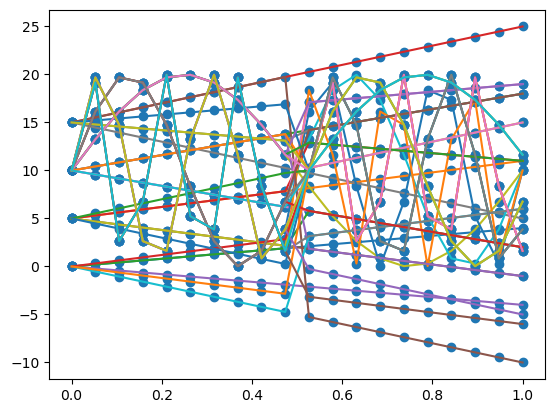

In [252]:
env = HandCraftedFunctions(max_steps=20, save_data=True)
inputs, seq_lens, targets, inputs= env.sample_batch()
idx = np.arange(0, 40)
plt.plot(inputs.T[:,idx], targets.T[:,idx]);
plt.scatter(inputs.T[:,idx], targets.T[:,idx]);
plt.savefig("figure_0.png", dpi=300, bbox_inches="tight")
plt.show()

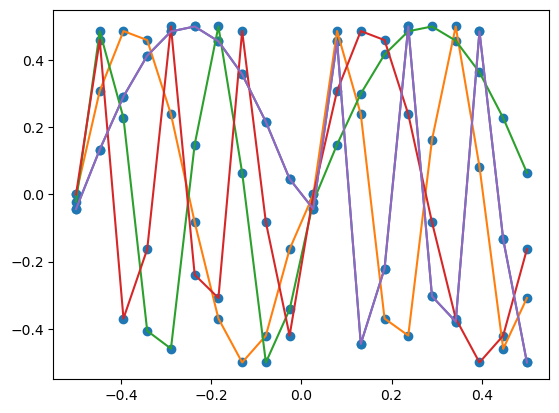

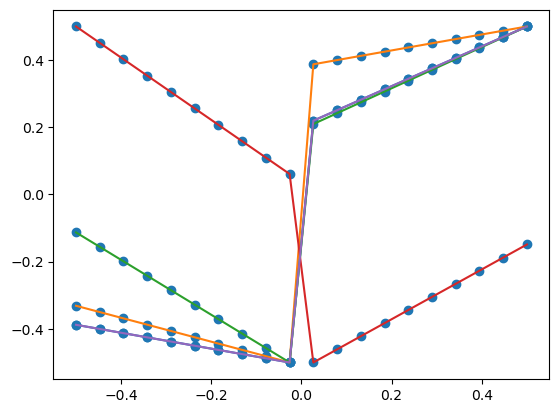

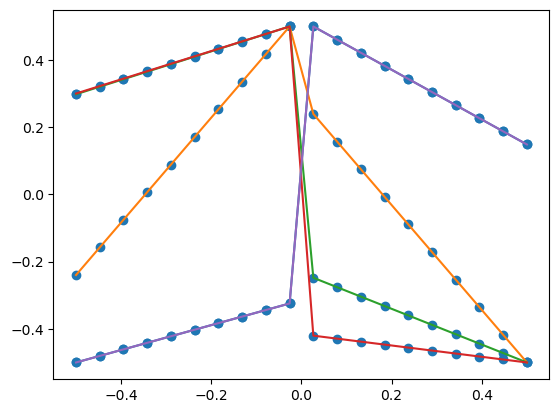

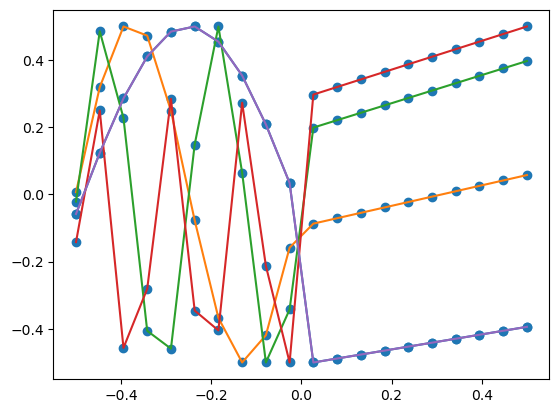

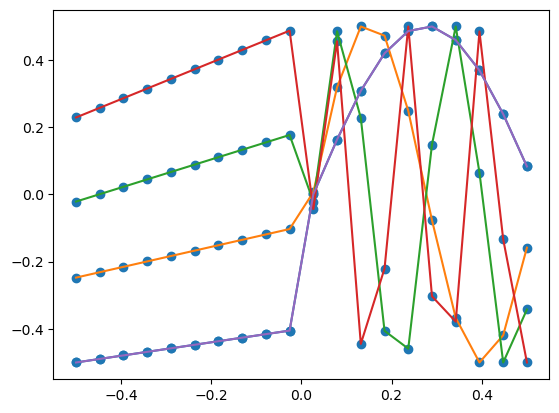

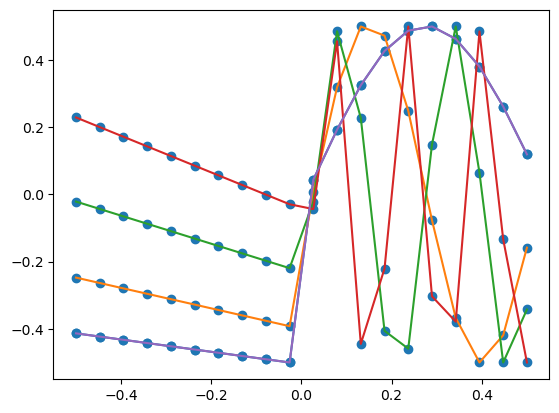

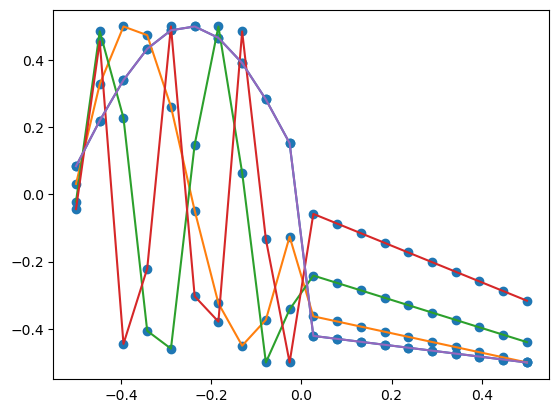

In [197]:
# env = HandCraftedFunctions(function='pos_linear', max_steps=20)
# env.batch_size = 6
# inputs, seq_lens, targets, inputs= env.sample_batch()

# idx = np.arange(0, 5)
# plt.plot(inputs.T[:,idx], targets.T[:,idx]);
# plt.scatter(inputs.T[:,idx], targets.T[:,idx]);
# plt.show()

# env = HandCraftedFunctions(function='neg_linear', max_steps=20)
# env.batch_size = 6
# inputs, seq_lens, targets, inputs= env.sample_batch()

# idx = np.arange(0, 5)
# plt.plot(inputs.T[:,idx], targets.T[:,idx]);
# plt.scatter(inputs.T[:,idx], targets.T[:,idx]);
# plt.show()

env = HandCraftedFunctions(max_steps=20)
env.batch_size = 6
inputs, seq_lens, targets, inputs= env.sample_batch(function='periodic_periodic')
idx = np.arange(0, 5)
plt.plot(inputs.T[:,idx], targets.T[:,idx]);
plt.scatter(inputs.T[:,idx], targets.T[:,idx]);
plt.savefig("figure_0.png", dpi=300, bbox_inches="tight")
plt.show()

env = HandCraftedFunctions(max_steps=20)
env.batch_size = 6
inputs, seq_lens, targets, inputs= env.sample_batch(function='neg_pos_linear',)
idx = np.arange(0, 5)
plt.plot(inputs.T[:,idx], targets.T[:,idx]);
plt.scatter(inputs.T[:,idx], targets.T[:,idx]);
plt.savefig("figure_1.png", dpi=300, bbox_inches="tight")
plt.show()

env = HandCraftedFunctions(max_steps=20)
env.batch_size = 6
inputs, seq_lens, targets, inputs= env.sample_batch(function='pos_neg_linear',)
idx = np.arange(0, 5)
plt.plot(inputs.T[:,idx], targets.T[:,idx]);
plt.scatter(inputs.T[:,idx], targets.T[:,idx]);
plt.savefig("figure_2.png", dpi=300, bbox_inches="tight")
plt.show()

env = HandCraftedFunctions(max_steps=20)
env.batch_size = 6
inputs, seq_lens, targets, inputs= env.sample_batch(function='periodic_pos_linear', )
idx = np.arange(0, 5)
plt.plot(inputs.T[:,idx], targets.T[:,idx]);
plt.scatter(inputs.T[:,idx], targets.T[:,idx]);
plt.savefig("figure_3.png", dpi=300, bbox_inches="tight")
plt.show()
env = HandCraftedFunctions(max_steps=20)
env.batch_size = 6
inputs, seq_lens, targets, inputs= env.sample_batch(function='pos_linear_periodic',)
idx = np.arange(0, 5)
plt.plot(inputs.T[:,idx], targets.T[:,idx]);
plt.scatter(inputs.T[:,idx], targets.T[:,idx]);
plt.savefig("figure_4.png", dpi=300, bbox_inches="tight")
plt.show()
env = HandCraftedFunctions(max_steps=20)
env.batch_size = 6
inputs, seq_lens, targets, inputs= env.sample_batch(function='neg_linear_periodic',)
idx = np.arange(0, 5)
plt.plot(inputs.T[:,idx], targets.T[:,idx]);
plt.scatter(inputs.T[:,idx], targets.T[:,idx]);
plt.savefig("figure_5.png", dpi=300, bbox_inches="tight")
plt.show()

env = HandCraftedFunctions(max_steps=20)
env.batch_size = 6
inputs, seq_lens, targets, inputs= env.sample_batch(function='periodic_neg_linear', )
idx = np.arange(0, 5)
plt.plot(inputs.T[:,idx], targets.T[:,idx]);
plt.scatter(inputs.T[:,idx], targets.T[:,idx]);
plt.savefig("figure_6.png", dpi=300, bbox_inches="tight")
plt.show()